In [1]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots


In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
from analysis import Analysis

PyHEADTAIL v1.16.5


# Ensemble of particles with no sc

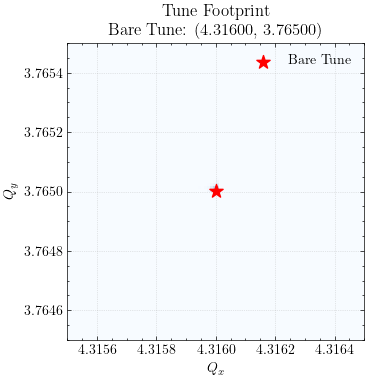

In [3]:
analysis = Analysis('data/no_sc')
analysis.tune_histogram(x_lims=(4.3155,4.3165), y_lims=(3.7645,3.7655))

# Ensemble of particle with varying sc

#####################################
10000000000.0
mine


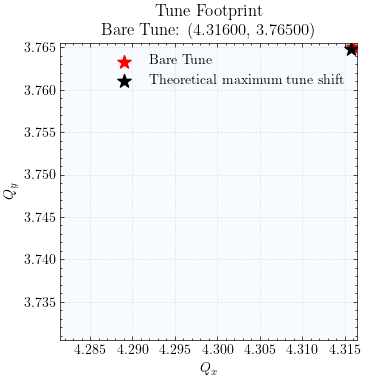

xfield


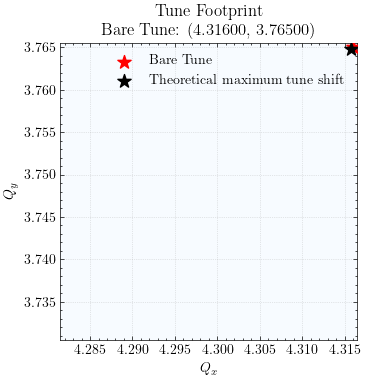

#####################################
40000000000.0
mine


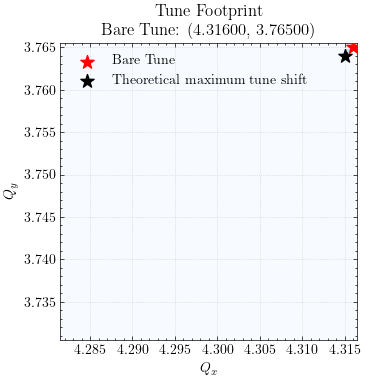

xfield


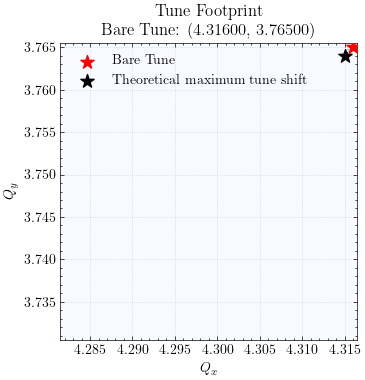

#####################################
100000000000.0
mine


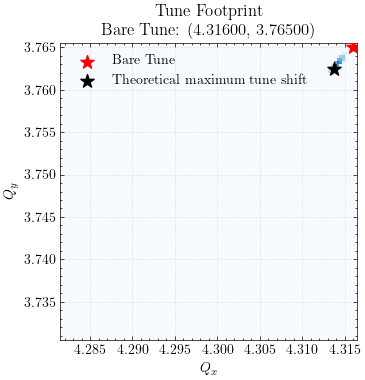

xfield


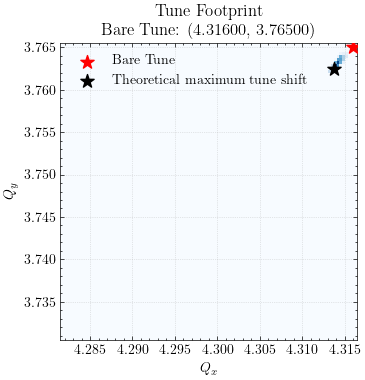

#####################################
400000000000.0
mine


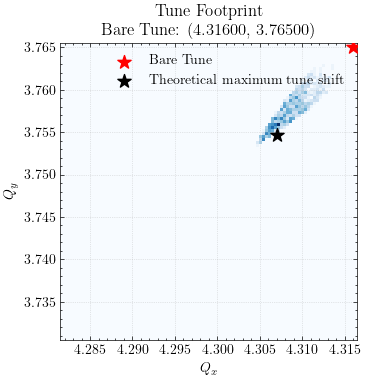

xfield


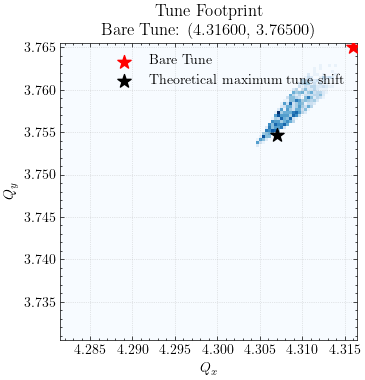

#####################################
1000000000000.0
mine


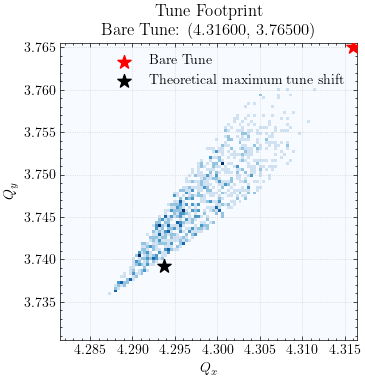

xfield


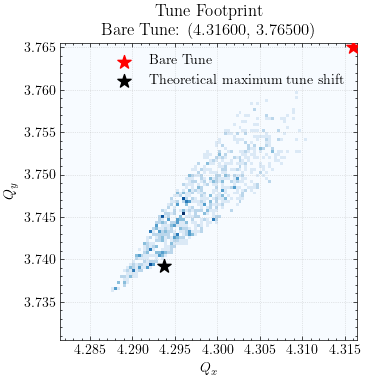

In [4]:
beam_intensity_list = [1e10, 4e10, 1e11, 4e11, 1e12]

max_detune_x_list = []
max_detune_y_list = []
max_detune_x_xf_list = []
max_detune_y_xf_list = []

mean_detune_x_list = []
mean_detune_y_list = []
mean_detune_x_xf_list = []
mean_detune_y_xf_list = []

theory_detune_x_list = []
theory_detune_y_list = []

for beam_intensity in beam_intensity_list:
    print('#####################################')
    print(beam_intensity)
    print('mine')
    analysis = Analysis(f'data/sweep_beam_intensity/{beam_intensity}')
    analysis.tune_histogram(x_lims=(4.2815,4.3165), 
                            y_lims=(3.7305,3.7655)
                           )
    max_detune_x_list.append(np.max(analysis.qx-analysis.Qx))
    max_detune_y_list.append(np.max(analysis.qy-analysis.Qy))
    mean_detune_x_list.append(np.mean(analysis.qx-analysis.Qx))
    mean_detune_y_list.append(np.mean(analysis.qy-analysis.Qy))
    
    theory_detune_x_list.append(analysis.DQx)
    theory_detune_y_list.append(analysis.DQy)

    
    print('xfield')
    analysis = Analysis(f'data/sweep_beam_intensity/xf_{beam_intensity}')
    analysis.tune_histogram(x_lims=(4.2815,4.3165), 
                            y_lims=(3.7305,3.7655))
   
    max_detune_x_xf_list.append(np.max(analysis.qx-analysis.Qx))
    max_detune_y_xf_list.append(np.max(analysis.qy-analysis.Qy))
    mean_detune_x_xf_list.append(np.mean(analysis.qx-analysis.Qx))
    mean_detune_y_xf_list.append(np.mean(analysis.qy-analysis.Qy))

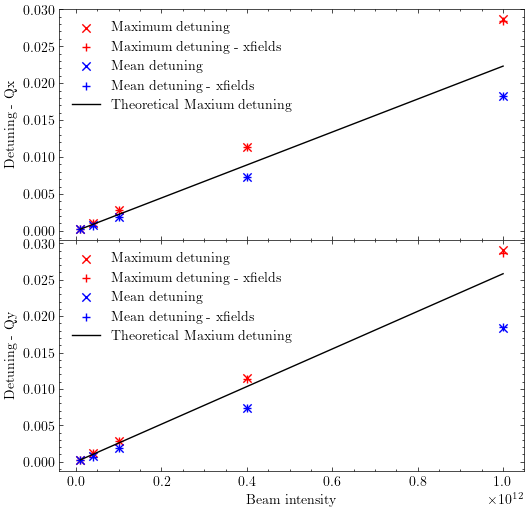

In [5]:
fig, axs = plt.subplots(2, figsize=(6,6), sharex=True)
plt.subplots_adjust(hspace=0)
axs[0].scatter(beam_intensity_list, max_detune_x_list, marker='x', c='r', label='Maximum detuning')
axs[0].scatter(beam_intensity_list, max_detune_x_xf_list, marker='+', c='r', label='Maximum detuning - xfields')
axs[0].scatter(beam_intensity_list, mean_detune_x_list, marker='x', c='b', label='Mean detuning')
axs[0].scatter(beam_intensity_list, mean_detune_x_xf_list, marker='+', c='b', label='Mean detuning - xfields')
axs[0].plot(beam_intensity_list, theory_detune_x_list, c='k', label='Theoretical Maxium detuning')
axs[0].set_ylabel('Detuning - Qx')
axs[0].legend()

axs[1].scatter(beam_intensity_list, max_detune_y_list, marker='x', c='r', label='Maximum detuning')
axs[1].scatter(beam_intensity_list, max_detune_y_xf_list, marker='+', c='r', label='Maximum detuning - xfields')
axs[1].scatter(beam_intensity_list, mean_detune_y_list, marker='x', c='b', label='Mean detuning')
axs[1].scatter(beam_intensity_list, mean_detune_y_xf_list, marker='+', c='b', label='Mean detuning - xfields')
axs[1].plot(beam_intensity_list, theory_detune_y_list, c='k', label='Theoretical Maxium detuning')
axs[1].set_xlabel('Beam intensity')
axs[1].set_ylabel('Detuning - Qy')
axs[1].legend()
plt.show()

# Ensemble of particles based on Haroon's params

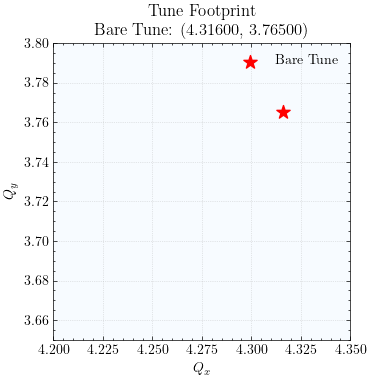

In [9]:
analysis = Analysis(f'data/haroon_bare')
analysis.tune_histogram(x_lims=(4.2,4.35), 
                        y_lims=(3.65,3.8))

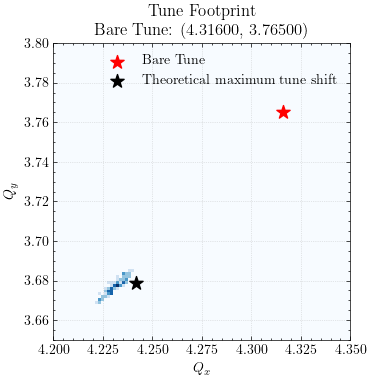

In [11]:
analysis = Analysis(f'data/haroon_sc')
analysis.tune_histogram(x_lims=(4.2,4.35), 
                        y_lims=(3.65,3.8))

In [12]:
sum(analysis.survivor_mask)

np.int64(93)

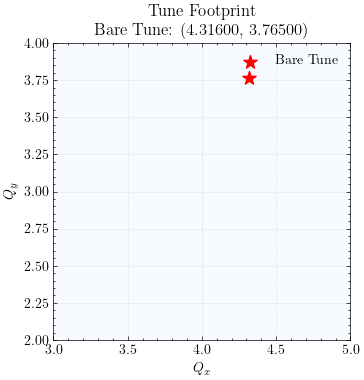

In [33]:
analysis = Analysis(f'data/haroon_bare')
analysis.tune_histogram(x_lims=(3,5), 
                        y_lims=(2,4))

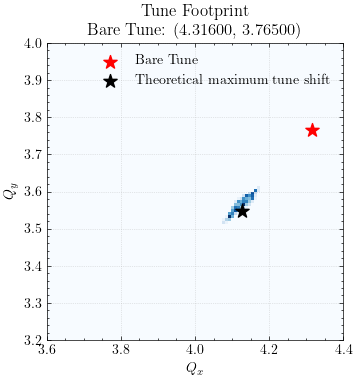

In [37]:
analysis = Analysis(f'data/haroon_sc_2')
analysis.tune_histogram(x_lims=(3.6,4.4), 
                        y_lims=(3.2,4))

In [31]:
print(np.sum(analysis.survivor_mask))

365


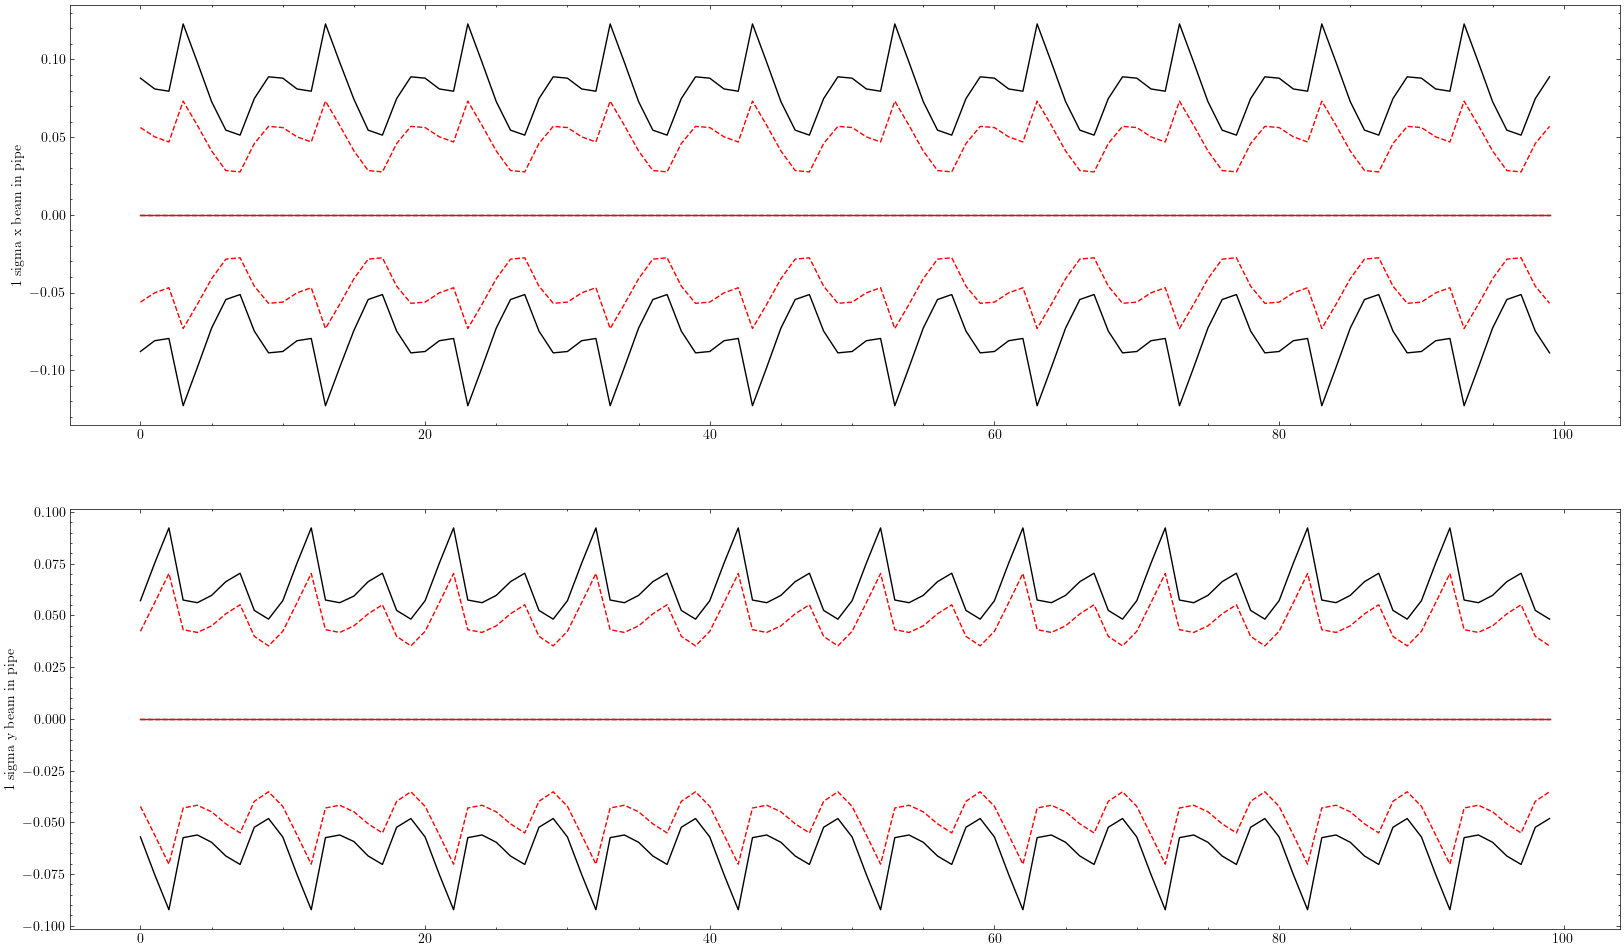

In [38]:
analysis.plot_field_in_pipe()

# Varying emittance with Haroon's Params

0.2


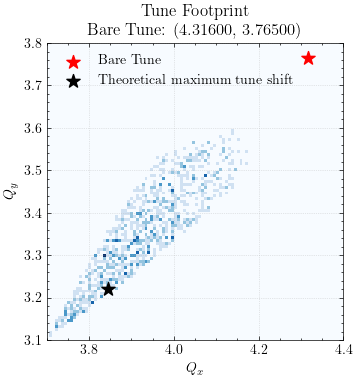

96.3%
0.22


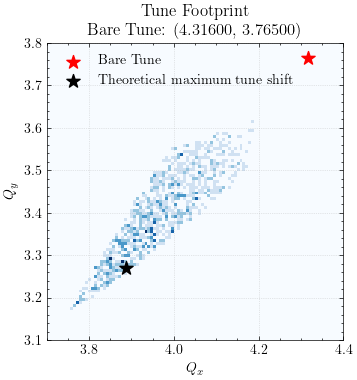

95.8%
0.24


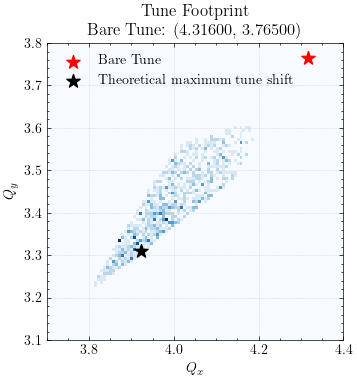

94.9%
0.26


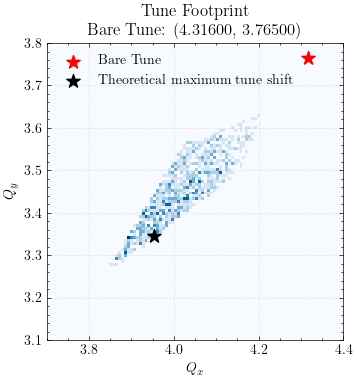

92.6%
0.28


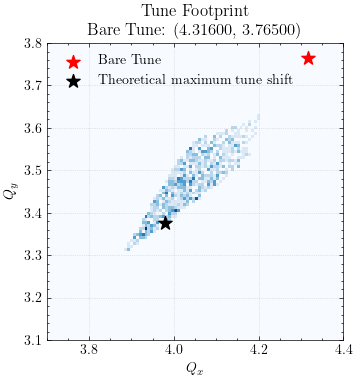

92.1%
0.3


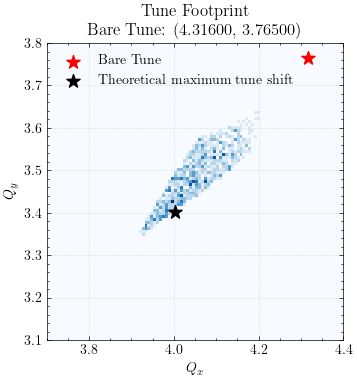

88.7%


In [55]:
factor_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1]

factor_list = [0.22, 0.24, 0.26, 0.28]

factor_list = [0.2, 0.22, 0.24, 0.26, 0.28, 0.3]
for factor in factor_list:
    print(factor)
    analysis = Analysis(f'data/sweep_factor_2/{factor}')
    analysis.tune_histogram(x_lims=(3.7,4.4), 
                            y_lims=(3.1,3.8))
    print(f'{np.sum(analysis.survivor_mask)/10}%')